# Who beat the baseline? (2024 House over-performance)

Second notebook on the [Open-Source-Election](https://github.com/903124/Open-Source-Election) data. Question: which 2024 House candidates ran ahead of their district's environment, and which ran behind it?

Environment = two signals, averaged where both exist:

- **P** — how the district voted for president. District-level, from the repo's lean pipeline (county presidential votes allocated to districts by area share).
- **S** — how the candidate's state voted across all state-senate and state-house general races, in raw votes. State-level only, because state-leg districts don't nest inside congressional ones.

`expected D share = 0.7·P + 0.3·S` where S exists, else just P. Over-performance = actual two-party share − expected share.

Uncontested races are excluded at every layer: a race counts only if both major parties filed and the loser cleared 5% of the two-party vote — a walkover measures the filing deadline, not the candidate. That drops 42 of 441 House seats (every seat and reason printed in section 1). On the state-leg side it matters more: about 40% of 2024 races had no real opposition, and their one-sided totals poison a raw vote sum — Wyoming's baseline moves 32 points once they're dropped. The export's incumbent flag is unreliable (exactly 1 district flagged), so incumbency is rebuilt here: same person won the same seat in 2022.

| thing | comes from |
|---|---|
| House results | `data/house/house_results_2024.csv` (+ `2022` for incumbency) |
| presidential baseline | `data/district_lean/district_lean_2024.csv` |
| state-leg baseline | `data/state_senate/`, `data/state_house/` (2024, contested only) |

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path("../Open-Source-Election")
          # notebook lives inside the repo
if not (REPO / "data").exists():
    REPO = Path("..")

pd.options.display.float_format = "{:.1f}".format
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11,
})

PARTY_COLOR = {"d": "#2a6fdb", "r": "#d94040"}
DEM_RE = re.compile(r"^democratic|^dfl")   # DFL / Democratic-NPL count as D


def party_class(p):
    p = str(p or "").strip().lower()
    return "d" if DEM_RE.match(p) else "r" if p == "republican" else "o"

print("pandas", pd.__version__)


pandas 2.2.3


## 1 · The actual result: two-party shares per district

The House CSV is candidate-level percentages of the total vote. Two fixes: Alaska's ranked-choice tabulation lists each candidate once per round — keep the final round (highest percentage); and third-party lines fold out through two-party normalization, candidate % ÷ (D % + R %) in the district.

In [2]:
house = pd.read_csv(REPO / "data/house/house_results_2024.csv")
house["pc"] = house["party"].map(party_class)

house = (house.sort_values("percentage")
              .drop_duplicates(["state_code", "district", "candidate"],
                               keep="last"))          # keep final RCV round

def dist_id(r):
    d = str(r["district"])
    num = d.upper() if not d.isdigit() else f"{int(d):02d}"
    return f"{r['state_code']}-{num}"

house["dist_id"] = house.apply(dist_id, axis=1)

dr = house[house["pc"].isin(["d", "r"])]
dr_pct = dr.groupby("dist_id")["percentage"].sum()      # sanity: ~100
d_pct = dr[dr["pc"] == "d"].groupby("dist_id")["percentage"].sum()
r_pct = dr[dr["pc"] == "r"].groupby("dist_id")["percentage"].sum()

dist = (100 * d_pct.reindex(dr_pct.index) / dr_pct).rename(
    "actual_d_share").to_frame()

meta = (house.sort_values("percentage")
             .groupby("dist_id")
             .agg(winner=("candidate", "last"),        # top % = the winner
                  winner_party=("pc", "last"),
                  state_code=("state_code", "first")))
dist = dist.join(meta)

# ---- the uncontested screen -------------------------------------------------
# contested = both major parties on the ballot AND the loser cleared 5% of
# the two-party vote. Everything else is a walkover; excluded with reasons.
no_major = sorted(set(house["dist_id"]) - set(dr_pct.index))
no_d = sorted(set(dr_pct.index) - set(d_pct.index))
no_r = sorted(set(dr_pct.index) - set(r_pct.index))
dist["loser_two_party"] = 100 - np.maximum(dist["actual_d_share"],
                                           100 - dist["actual_d_share"])

reason = pd.Series(np.nan, index=dist.index, dtype=object)
reason[dist["actual_d_share"].isna()] = "no D filing"
reason[dist.index.isin(no_r)] = "no R filing"
reason[reason.isna() & dist["loser_two_party"].lt(5)] = "token opponent (<5%)"

excluded = pd.concat([
    pd.DataFrame({"dist_id": no_major, "reason": "no major-party filing"}),
    reason.dropna().rename("reason").reset_index(),
]).sort_values("dist_id").reset_index(drop=True)
for r_name, grp in excluded.groupby("reason")["dist_id"]:
    print(f"{r_name} ({len(grp)}):\n  {', '.join(grp)}")
n_all = house["dist_id"].nunique()
print(f"\nexcluded {len(excluded)} of {n_all} seats "
      f"-> {n_all - len(excluded)} contested")
dist = dist[reason.isna()]
dist.head(4)


no D filing (20):
  AL-03, AL-04, AL-05, CA-20, IL-15, IL-16, KY-04, KY-05, LA-04, MS-03, NC-03, NC-06, NV-02, OK-03, TX-01, TX-11, TX-13, TX-19, TX-25, WA-04
no R filing (20):
  CA-12, CA-16, CA-34, CA-37, CO-01, CO-02, FL-20, MA-01, MA-02, MA-03, MA-04, MA-05, MA-06, MA-07, MI-06, PA-03, TX-09, TX-20, TX-30, WA-09
no major-party filing (2):
  AS-AL, PR-AL

excluded 42 of 441 seats -> 399 contested


,actual_d_share,winner,winner_party,state_code,loser_two_party
dist_id,,,,,
AK-AL,49.3,Nick Begich III,r,AK,49.3
AL-01,21.5,Barry Moore,r,AL,21.5
AL-02,54.6,Shomari Figures,d,AL,45.4
AL-06,29.6,Gary Palmer,r,AL,29.6


## 2 · Two baselines

P comes straight from the lean pipeline. S is built here, and the uncontested screen bites hardest here: sum state-senate and state-house general votes by party, contested races only, then D / (D + R), averaging the two chambers when both exist. Nebraska's nonpartisan unicameral, Alaska's coalition politics, and a few wiki coverage gaps leave no D-vs-R vote to sum — those fall back to presidential-only, flagged. The cell prints which states' baselines move.

The blend is 70/30 toward P: P is district-level, S only state-level. Where S doesn't exist it's P alone.

In [3]:
lean = pd.read_csv(REPO / "data/district_lean/district_lean_2024.csv")
P = lean.set_index("district")["d_share_two_party_pct"]
dist = dist.join(P.rename("pres_d_share"))

n = dist["pres_d_share"].notna().sum()
print(f"presidential baseline: {n}/{len(dist)} districts")
print("missing:", dist.index[dist["pres_d_share"].isna()].tolist())


presidential baseline: 396/399 districts
missing: ['GU-AL', 'MP-AL', 'VI-AL']


In [4]:
def chamber_shares(sub, contested_only):
    leg = pd.read_csv(REPO / f"data/{sub}/{sub}_results_2024.csv")
    leg = leg[leg["race"] == "general"]
    leg["pc"] = leg["party"].map(party_class)
    per_race = (leg[leg["pc"].isin(["d", "r"])]
                .groupby(["state_code", "district", "pc"])["votes"]
                .sum().unstack())
    dv = per_race["d"].fillna(0) if "d" in per_race else per_race["r"] * 0
    rv = per_race["r"].fillna(0)
    two = dv + rv
    loser = np.where(two > 0, np.minimum(dv, rv) / two * 100, 0.0)
    keep = (dv > 0) & (rv > 0) & (loser >= 5)
    if not contested_only:
        keep = pd.Series(True, index=per_race.index)
    v = (pd.DataFrame({"d": dv[keep], "r": rv[keep]})
         .groupby(level="state_code").sum())
    return 100 * v["d"] / (v["d"] + v["r"]), int((~keep).sum()), len(per_race)


chambers, chamber_all = {}, {}
for label, sub in [("senate", "state_senate"), ("house", "state_house")]:
    share, n_unc, n_races = chamber_shares(sub, contested_only=True)
    chambers[label] = share.rename(f"{label} D share")
    chamber_all[label] = chamber_shares(sub, contested_only=False)[0]
    print(f"{label}: {n_races} races, {n_unc} uncontested -> dropped "
          f"({n_races - n_unc} contested), {share.notna().sum()} states usable")

S = pd.DataFrame(chambers)
S["stateleg_d_share"] = S.mean(axis=1)

# what the screen changed, state by state
S_all = pd.DataFrame(chamber_all)
S_all["stateleg_d_share"] = S_all.mean(axis=1)
shift = (S["stateleg_d_share"] - S_all["stateleg_d_share"]).dropna()
movers = shift[shift.abs() > 1].sort_values()
print(f"\ndropping uncontested races moves the state-leg baseline "
      f">1 point in {len(movers)} states:")
print(movers.round(1).to_string())
print("\nstates with no usable chamber:",
      sorted(set(dist["state_code"]) - set(S["stateleg_d_share"].dropna().index)))
S.dropna().head(6)


senate: 935 races, 383 uncontested -> dropped (552 contested), 33 states usable
house: 3008 races, 1174 uncontested -> dropped (1834 contested), 30 states usable

dropping uncontested races moves the state-leg baseline >1 point in 23 states:
state_code
RI   -20.7
WI   -10.1
NC    -8.2
TX    -8.1
DE    -6.2
NM    -5.3
VT    -1.7
FL    -1.5
CT    -1.3
MN    -1.3
KS     2.1
NV     2.6
IL     3.0
TN     3.8
IN     4.1
MT     5.8
SC     8.1
AR     9.4
UT    12.1
WV    13.8
SD    14.8
AK    18.5
WY    32.0

states with no usable chamber: ['AL', 'CA', 'CO', 'DC', 'GU', 'LA', 'MA', 'MD', 'MP', 'MS', 'ND', 'NE', 'NJ', 'OK', 'PA', 'VA', 'VI', 'WA']


,senate,house,stateleg_d_share
state_code,,,
AR,32.3,32.9,32.6
AZ,46.1,44.1,45.1
CT,55.5,53.8,54.6
DE,50.1,54.2,52.2
FL,39.0,39.7,39.4
GA,44.9,45.2,45.0


In [5]:
dist = dist.join(S["stateleg_d_share"], on="state_code")
W_P, W_S = 0.7, 0.3   # weight presidential (district-level) > state-leg (state-level)
def _blend(row):
    p, s = row["pres_d_share"], row["stateleg_d_share"]
    if pd.notna(p) and pd.notna(s):
        return W_P * p + W_S * s
    return p if pd.notna(p) else s
dist["expected_d_share"] = dist.apply(_blend, axis=1)
dist["over"] = dist["actual_d_share"] - dist["expected_d_share"]
dist["over_pres"] = dist["actual_d_share"] - dist["pres_d_share"]
dist["over_leg"] = dist["actual_d_share"] - dist["stateleg_d_share"]

n_both = dist[["pres_d_share", "stateleg_d_share"]].notna().all(axis=1).sum()
print(f"{n_both}/{len(dist)} districts use the blended baseline "
      f"(P×{W_P} + S×{W_S}); {len(dist) - n_both} are presidential-only")

# incumbency, rebuilt the honest way: same person won this seat in 2022
w22 = pd.read_csv(REPO / "data/house/house_results_2022.csv")
w22["dist_id"] = w22.apply(dist_id, axis=1)
prev = (w22[w22["winner"]].set_index("dist_id")["candidate"]
        .rename("winner_2022"))
dist = dist.join(prev)
dist["incumbent"] = dist["winner"] == dist["winner_2022"]

print(f"2022 winners matched onto 2024 winners: "
      f"{dist['incumbent'].sum()} incumbents, "
      f"{(~dist['incumbent']).sum()} new to the seat\n")
dist["over"].describe()


265/399 districts use the blended baseline (P×0.7 + S×0.3); 134 are presidential-only
2022 winners matched onto 2024 winners: 324 incumbents, 75 new to the seat



count   396.0
mean      0.2
std       7.1
min     -19.8
25%      -4.4
50%      -1.0
75%       4.1
max      25.4
Name: over, dtype: float64

## 3 · The picture

Every point is a district. Below the diagonal = the winner underperformed the environment; above = ran ahead of it. The rules mark 50%.

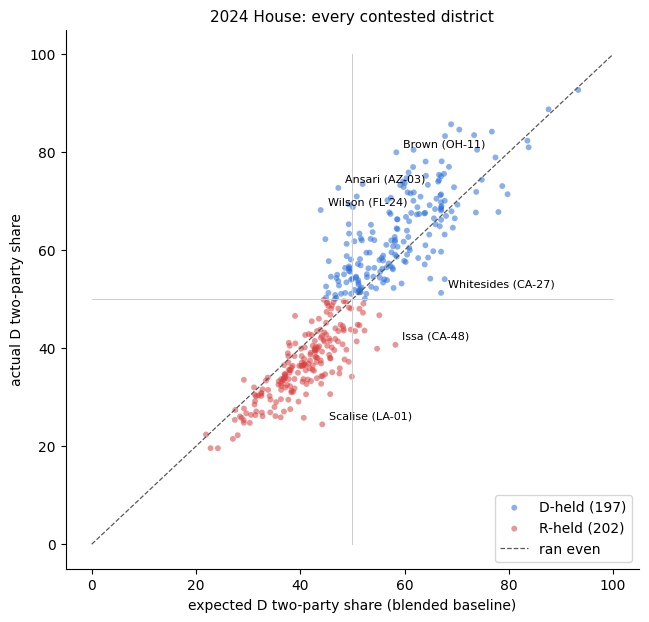

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 7.0))
for party, color in PARTY_COLOR.items():
    sub = dist[dist["winner_party"] == party]
    ax.scatter(sub["expected_d_share"], sub["actual_d_share"], s=18,
               alpha=0.55, color=color, edgecolor="none",
               label=f"{party.upper()}-held ({len(sub)})")
ax.plot([0, 100], [0, 100], color="0.35", lw=0.9, ls="--", label="ran even")
ax.plot([0, 100], [50, 50], color="0.8", lw=0.7)
ax.plot([50, 50], [0, 100], color="0.8", lw=0.7)
ax.set(xlabel="expected D two-party share (blended baseline)",
       ylabel="actual D two-party share",
       title="2024 House: every contested district")
ax.legend(loc="lower right")

extremes = pd.concat([dist.nlargest(3, "over"), dist.nsmallest(3, "over")])
for _, row in extremes.iterrows():
    ax.annotate(f"{row['winner'].split()[-1]} ({row.name})",
                (row["expected_d_share"], row["actual_d_share"]),
                fontsize=8, xytext=(5, 4), textcoords="offset points");


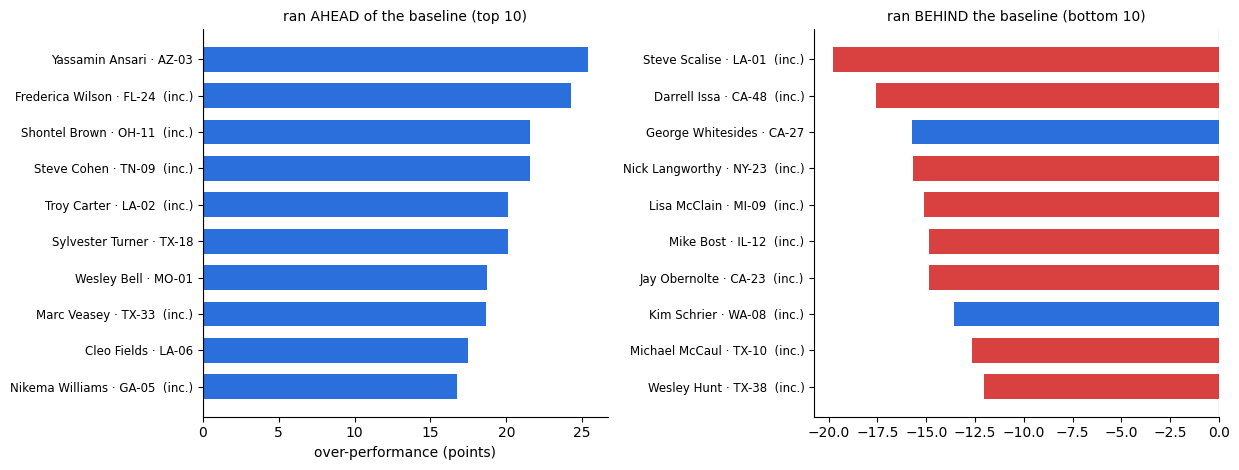


AHEAD — where each baseline lands:
          winner dist_id  actual_d_share  pres_d_share  stateleg_d_share  over_pres  over_leg  over  incumbent
 Yassamin Ansari   AZ-03            72.7          48.2              45.1       24.5      27.6  25.4      False
Frederica Wilson   FL-24            68.2          45.9              39.4       22.3      28.8  24.3       True
   Shontel Brown   OH-11            80.0          65.8              41.1       14.1      38.9  21.6       True
     Steve Cohen   TN-09            73.5          60.5              32.2       13.1      41.3  21.5       True
     Troy Carter   LA-02            71.0          50.8               NaN       20.1       NaN  20.1       True
Sylvester Turner   TX-18            69.4          52.8              41.1       16.6      28.3  20.1      False
     Wesley Bell   MO-01            80.5          70.0              42.4       10.5      38.1  18.8      False
     Marc Veasey   TX-33            68.8          54.0              41.1    

In [7]:
show = ["winner", "dist_id", "actual_d_share", "pres_d_share",
        "stateleg_d_share", "over_pres", "over_leg", "over", "incumbent"]

top = dist.nlargest(10, "over")
bot = dist.nsmallest(10, "over")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, frame, title in zip(
        axes, [top, bot],
        ["ran AHEAD of the baseline (top 10)",
         "ran BEHIND the baseline (bottom 10)"]):
    y = np.arange(len(frame))[::-1]
    ax.barh(y, frame["over"],
            color=[PARTY_COLOR[p] for p in frame["winner_party"]],
            height=0.68)
    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{w} · {d}" + ("  (inc.)" if i else "")
         for w, d, i in zip(frame["winner"], frame.index,
                            frame["incumbent"])],
        fontsize=8.5)
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set_title(title, fontsize=10)
axes[0].set_xlabel("over-performance (points)")
plt.tight_layout()
plt.show()
print("\nAHEAD — where each baseline lands:")
print(top.reset_index()[show].to_string(index=False))
print("\nBEHIND — where each baseline lands:")
print(bot.reset_index()[show].to_string(index=False))


### Spot-check against names you know

The cycle's famously resilient swing-seat members should show up positive in their own party's terms — Mike Lawler held a seat Harris won by double digits, Marie Gluesenkamp Perez held one Harris barely won. If the math is wrong, they won't be there.

In [8]:
famous = ["WA-03", "NY-17", "NE-02", "AZ-06", "IA-03", "CA-41", "OH-09",
          "CA-27"]
known = dist.loc[famous].copy()
sign = known["winner_party"].map({"d": 1, "r": -1})
known["over_own_party"] = known["over"] * sign
known[["winner", "winner_party", "actual_d_share", "expected_d_share",
       "over_own_party", "incumbent"]]


,winner,winner_party,actual_d_share,expected_d_share,over_own_party,incumbent
dist_id,,,,,,
WA-03,Marie Gluesenkamp Perez,d,51.9,50.4,1.5,True
NY-17,Mike Lawler,r,46.7,55.2,8.4,True
NE-02,Don Bacon,r,49.1,52.1,3.0,True
AZ-06,Juan Ciscomani,r,48.7,46.1,-2.6,True
IA-03,Zach Nunn,r,48.1,45.9,-2.2,True
CA-41,Ken Calvert,r,48.3,49.4,1.1,True
OH-09,Marcy Kaptur,d,50.4,44.9,5.4,True
CA-27,George Whitesides,d,51.3,67.0,-15.7,False


           over  over_pres
incumbent                 
False       0.2       -0.1
True        0.1       -0.6


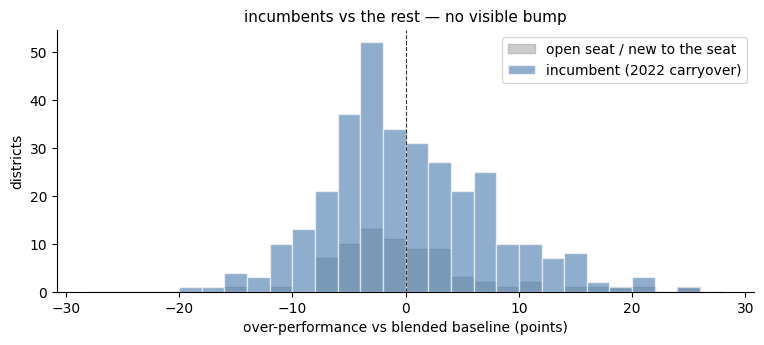

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.4))
bins = np.arange(-28, 29, 2)
ax.hist(dist.loc[~dist["incumbent"], "over"], bins=bins, color="0.8",
        edgecolor="0.75", label="open seat / new to the seat")
ax.hist(dist.loc[dist["incumbent"], "over"], bins=bins, color="#4477aa",
        alpha=0.6, edgecolor="white", label="incumbent (2022 carryover)")
ax.axvline(0, color="0.2", lw=0.8, ls="--")
ax.set_xlabel("over-performance vs blended baseline (points)")
ax.set_ylabel("districts")
ax.set_title("incumbents vs the rest — no visible bump")
ax.legend()
print(dist.groupby("incumbent")[["over", "over_pres"]].mean().round(1));


## Notes

- 399 of 441 seats survive the contested screen: 20 with no Democrat, 20 with no Republican, AS-AL and PR-AL with neither.
- Baseline coverage: P 396/399. S built from 552 of 935 senate and 1,834 of 3,008 house seats after the screen; dropping unopposed races moves 23 states >1 point (WY +32, AK +18, SD +15, WV +14).
- Blend: 265 districts use 0.7·P + 0.3·S, 134 presidential-only. Over-performance: mean +0.2, median −1.0, sd 7.1, range −19.8 to +25.4. Tilting toward P slightly lowers over-performance in majority-Black urban districts, where S runs ahead of P.
- Incumbents vs open seats: no visible bump (+0.1 vs +0.2).

Caveats: S is state-level, so `over_pres` and `over_leg` are kept alongside the blend to make disagreements visible. The 2024 redraws (AL, GA, LA, NY, NC) can break the 2022-winner incumbency carryover. P's area-share allocation can misfire in split-county seats — CA-27 is the textbook case (~67% allocated vs ~55% real). The top of the AHEAD list (FL-24, OH-11, TN-09, TX-18, GA-05) is mostly majority-Black urban districts — turnout composition more than personal vote.